In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Fraud-Detector-ML/Data/Fraud_Data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           590540 non-null  int64  
 1   is_fraud                 590540 non-null  int64  
 2   transaction_time         590540 non-null  int64  
 3   transaction_amount       590540 non-null  float64
 4   card_network             588963 non-null  object 
 5   card_type                588969 non-null  object 
 6   purchaser_email_domain   496084 non-null  object 
 7   device_type              140810 non-null  object 
 8   is_identity_seen_before  129340 non-null  object 
 9   user_os                  144233 non-null  object 
 10  user_browser             144233 non-null  object 
 11  environment              144233 non-null  object 
 12  environment_freq         144233 non-null  float64
 13  environment_risk         144233 non-null  float64
 14  devi

In [4]:
df = df.dropna(subset=['card_network', 'card_type'], how='any')

In [5]:
df['card_network'].unique()

array(['discover', 'mastercard', 'visa', 'american express'], dtype=object)

In [6]:
df['card_network'].value_counts(normalize=True) * 100

card_network
visa                65.330236
mastercard          32.127473
american express     1.413006
discover             1.129284
Name: proportion, dtype: float64

In [7]:
df['card_type'].unique()

array(['credit', 'debit', 'debit or credit', 'charge card'], dtype=object)

In [8]:
df['card_type'].value_counts()

card_type
debit              439929
credit             148983
debit or credit        30
charge card            15
Name: count, dtype: int64

In [9]:
df.drop(
    df[df['card_type'].isin(['debit or credit', 'charge card'])].index,
    axis=0,
    inplace=True
)


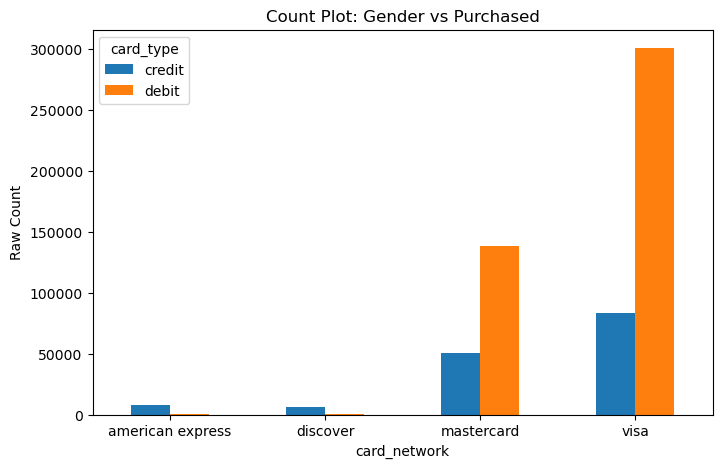

In [10]:
counts = pd.crosstab(df['card_network'], df['card_type'])
counts.plot(kind='bar', figsize=(8, 5))
plt.title('Count Plot: Gender vs Purchased')
plt.ylabel('Raw Count')
plt.xticks(rotation=0)
plt.show()

In [14]:
df['purchaser_email_domain'].fillna('NA', inplace=True)
df['purchaser_email_domain'].value_counts()

purchaser_email_domain
gmail.com           227680
yahoo.com           100654
NA                   94226
hotmail.com          45134
anonymous.com        36913
aol.com              28213
comcast.net           7869
icloud.com            6250
outlook.com           5082
msn.com               4082
att.net               4014
live.com              3035
sbcglobal.net         2962
verizon.net           2697
ymail.com             2387
bellsouth.net         1902
yahoo.com.mx          1540
me.com                1520
cox.net               1388
optonline.net         1008
charter.net            813
live.com.mx            744
rocketmail.com         664
mail.com               559
earthlink.net          514
gmail                  494
outlook.es             438
mac.com                436
juno.com               320
aim.com                314
hotmail.es             305
roadrunner.com         304
windstream.net         304
hotmail.fr             295
frontier.com           280
embarqmail.com         260
web.d

In [15]:
df['card_info'] = (df['card_network'] + '_' + df['card_type'])

In [16]:
df['card_info'].unique()

array(['discover_credit', 'mastercard_credit', 'visa_debit',
       'mastercard_debit', 'visa_credit', 'american express_credit',
       'discover_debit', 'american express_debit'], dtype=object)

In [19]:
df['environment_risk'].unique()

array([nan,  1.,  0.,  2.])

In [31]:
df['is_fraud'].value_counts()

is_fraud
0    568290
1     20622
Name: count, dtype: int64

In [ ]:
filtered = ((df["environment_risk"].isin([1, 2])) &
(df["is_fraud"] == 1))
filtered.sum()

np.int64(2289)

In [49]:
c_info = ['discover_credit', 'mastercard_credit', 'visa_debit',
       'mastercard_debit', 'visa_credit', 'american express_credit',
       'discover_debit', 'american express_debit']

c_net = ['discover', 'mastercard', 'visa', 'american express']

c_type = ['debit', 'credit']

print('Card info')
for col in c_info:
    total = (df["card_info"] == col).sum()
    
    fraud_count = (
        (df["card_info"] == col) &
        (df["is_fraud"] == 1)
    ).sum()
    
    percentage = (fraud_count / total) * 100 if total != 0 else 0
    
    print(f"{col}: {percentage:.2f}% ----------- Counts {total}")

print('Card network')
for col in c_net:
    total = (df["card_network"] == col).sum()
    
    fraud_count = (
        (df["card_network"] == col) &
        (df["is_fraud"] == 1)
    ).sum()
    
    percentage = (fraud_count / total) * 100 if total != 0 else 0
    
    print(f"{col}: {percentage:.2f}% ----------- Counts {total}")

print('Card type')
for col in c_type:
    total = (df["card_type"] == col).sum()
    
    fraud_count = (
        (df["card_type"] == col) &
        (df["is_fraud"] == 1)
    ).sum()
    
    percentage = (fraud_count / total) * 100 if total != 0 else 0
    
    print(f"{col}: {percentage:.2f}% ----------- Counts {total}")

Card info
discover_credit: 7.93% ----------- Counts 6304
mastercard_credit: 6.92% ----------- Counts 50772
visa_debit: 2.55% ----------- Counts 301023
mastercard_debit: 2.16% ----------- Counts 138415
visa_credit: 6.81% ----------- Counts 83732
american express_credit: 2.86% ----------- Counts 8175
discover_debit: 4.03% ----------- Counts 347
american express_debit: 3.47% ----------- Counts 144
Card network
discover: 7.73% ----------- Counts 6651
mastercard: 3.43% ----------- Counts 189187
visa: 3.48% ----------- Counts 384755
american express: 2.87% ----------- Counts 8319
Card type
debit: 2.43% ----------- Counts 439929
credit: 6.68% ----------- Counts 148983


array(['discover', 'mastercard', 'visa', 'american express'], dtype=object)